# Pandas and plotting using matplotlib

---

En esta libreta se intentan recrear las graficas y el procesamiento del dataframe hecho en las clases 04 a 07, sin ver las notas.

## Librerias

---

In [233]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import re
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import math
from pywaffle import waffle

# Lectura de datos

In [234]:
tks = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "JNJ", "XOM","^GSPC"]

inicio = "2021-01-01"
final = "2025-12-31"

data = yf.download(tickers=tks, start=inicio, end=final, auto_adjust=False, progress=True, threads=True)
display(data)

[*********************100%***********************]  11 of 11 completed


Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-01-04  125.856697  159.331497   85.599022  135.059647  109.491570   
2021-01-05  127.412727  160.925507   86.289314  136.647537  110.087326   
2021-01-06  123.123863  156.919006   85.437843  137.933441  115.256592   
2021-01-07  127.325256  158.108002   87.989769  138.399460  119.041534   
2021-01-08  128.424210  159.134995   89.154640  138.114639  119.172958   
...                ...         ...         ...         ...         ...   
2025-12-23  272.105377  232.139999  314.128876  204.691833  322.814331   
2025-12-24  273.554016  232.380005  313.869049  206.681259  326.023376   
2025-12-26  273.144409  232.520004  313.289459  206.532059  324.775421   
2025-12-29  273.504089  232.070007  313.339417  206.462418  320.655182   
2025-12-30  272.824707  232.529999  313.629242  205.815857  320.328369   

Price                                                                   ...  \
Ticker            META        MSFT        NVDA        TSLA         XOM  ...   
Date                                                                    ...   
2021-01-04  266.845886  208.406540   13.076017  243.256668   33.693798  ...   
2021-01-05  268.860107  208.607544   13.366438  245.036667   35.317585  ...   
2021-01-06  261.259796  203.198532   12.578445  251.993332   36.218796  ...   
2021-01-07  266.647461  208.980942   13.305858  272.013336   36.502956  ...   
2021-01-08  265.486633  210.254211   13.238799  293.339996   36.908913  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-23  664.371155  485.741333  189.199768  485.559998  118.629288  ...   
2025-12-24  666.978943  486.908630  188.599792  485.399994  118.430618  ...   
2025-12-26  662.722595  486.599365  190.519684  475.190002  118.321342  ...   
2025-12-29  658.126526  485.990753  188.209808  459.640015  119.731941  ...   
2025-12-30  665.380310  486.369904  187.529846  454.429993  120.188896  ...   

Price         Volume                                                    \
Ticker          AMZN     GOOGL       JNJ       JPM      META      MSFT   
Date                                                                     
2021-01-04  88228000  37324000  11765900  16819900  15106100  37130100   
2021-01-05  53110000  20360000   9602300  13731200   9871600  23823000   
2021-01-06  87896000  46588000   8230100  24909100  24354100  35930700   
2021-01-07  70290000  41936000   7747200  21940400  15789800  27694500   
2021-01-08  70754000  35484000   8228900  12035100  18528300  22956200   
...              ...       ...       ...       ...       ...       ...   
2025-12-23  29230200  25478700   7047300   6668300   8486800  14683600   
2025-12-24  11420500  10097400   2376500   4289300   5627500   5855900   
2025-12-26  15994700  10899000   2316700   4158300   7133800   8842200   
2025-12-29  19797900  19621800   4348900   8635300   8506500  10893400   
2025-12-30  21910500  17380900   3937400   7904300   9187500  13944500   

Price                                                   
Ticker           NVDA       TSLA       XOM       ^GSPC  
Date                                                    
2021-01-04  560640000  145914600  27764700  5015000000  
2021-01-05  322760000   96735600  44035100  4591020000  
2021-01-06  580424000  134100000  36484800  6064110000  
2021-01-07  461480000  154496700  29528100  5099160000  
2021-01-08  292528000  225166500  28628200  4773040000  
...               ...        ...       ...         ...  
2025-12-23  174873600   58223600  12567600  3820560000  
2025-12-24   65528500   41285400   6137400  1798270000  
2025-12-26  139740300   58780700   8066100  2586550000  
2025-12-29  120006100   66263000  14782500  3541750000  
2025-12-30   97687300   59238500  11150500  3309930000  

[1254 rows x 66 colu

## Objetivos

- [x] Preparar dataframe para visualizacion de datos
- [x] Histograma de precios ajustados ticker AMAZON
- [x] Histograma de rendimientos ajustados ticker AMAZON
- [x] Histograma de rendimientos ajustados todos los tickers
- [x] Heatmap matriz de correlacion de precios ajustados
- [x] Heatmap correlacion de rendimientos
- [x] Boxplot de precios ajustados ticker AMZN y GOOGL
- [ ] Serie de tiempo, precios ajustados de cierre INICIO - FIN
- [ ] Serie de tiempo, evolucion del precio de la accion ticker AMAZON con respecto al ano anterior y hace dos anos con area
- [x] Dsitribucion de pesos en la cardeta, pie
- [ ] Proporcion del rendimiento total acumulado por accion para el 2025 pi 9 pm
- [ ] Grafico de barras rendimiento acumulado del ultimo ano por accion
- [ ] Grafico de barras con rendimiento acumulado del portafolio para el 2025 10 pm
- [ ] Grouped barchart, precio de cierre por accion ultimos 4 anos
- [ ] Grouped barchart, rendimiento maximo, minimo y promedio por accion 10pm 11 pm

Extra:

- waffle chart
- stacked barchart
- bubble plot
- scatter plot
- tabla

## EDA

---


In [235]:
display(data.columns.tolist())

[('Adj Close', 'AAPL'),
 ('Adj Close', 'AMZN'),
 ('Adj Close', 'GOOGL'),
 ('Adj Close', 'JNJ'),
 ('Adj Close', 'JPM'),
 ('Adj Close', 'META'),
 ('Adj Close', 'MSFT'),
 ('Adj Close', 'NVDA'),
 ('Adj Close', 'TSLA'),
 ('Adj Close', 'XOM'),
 ('Adj Close', '^GSPC'),
 ('Close', 'AAPL'),
 ('Close', 'AMZN'),
 ('Close', 'GOOGL'),
 ('Close', 'JNJ'),
 ('Close', 'JPM'),
 ('Close', 'META'),
 ('Close', 'MSFT'),
 ('Close', 'NVDA'),
 ('Close', 'TSLA'),
 ('Close', 'XOM'),
 ('Close', '^GSPC'),
 ('High', 'AAPL'),
 ('High', 'AMZN'),
 ('High', 'GOOGL'),
 ('High', 'JNJ'),
 ('High', 'JPM'),
 ('High', 'META'),
 ('High', 'MSFT'),
 ('High', 'NVDA'),
 ('High', 'TSLA'),
 ('High', 'XOM'),
 ('High', '^GSPC'),
 ('Low', 'AAPL'),
 ('Low', 'AMZN'),
 ('Low', 'GOOGL'),
 ('Low', 'JNJ'),
 ('Low', 'JPM'),
 ('Low', 'META'),
 ('Low', 'MSFT'),
 ('Low', 'NVDA'),
 ('Low', 'TSLA'),
 ('Low', 'XOM'),
 ('Low', '^GSPC'),
 ('Open', 'AAPL'),
 ('Open', 'AMZN'),
 ('Open', 'GOOGL'),
 ('Open', 'JNJ'),
 ('Open', 'JPM'),
 ('Open', 'META'),


In [236]:
display(data.index)

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', name='Date', length=1254, freq=None)

## Limpieza de datos

---

Primero, eliminamos el multiindex y cambioamos nombres del index y del column index

In [237]:
df = data.copy()


new_columns = []
for lista in df.columns.tolist():
    new_column_name = (lista[0] + " " + lista[1]).strip().upper().replace(" ", '_').strip("-")
    new_column_name = re.sub(r"[^A-Z_]", "", new_column_name)
    new_column_name = re.sub(r"_+", "_", new_column_name)
    new_columns.append(new_column_name)

df.columns = new_columns
df.index.name = ""
df.insert(0, "Date", df.index.values)
df = df.reset_index(drop=True)

display(df)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,VOLUME_GSPC
0,2021-01-04,125.856697,159.331497,85.599022,135.059647,109.491570,266.845886,208.406540,13.076017,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,5015000000
1,2021-01-05,127.412727,160.925507,86.289314,136.647537,110.087326,268.860107,208.607544,13.366438,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,4591020000
2,2021-01-06,123.123863,156.919006,85.437843,137.933441,115.256592,261.259796,203.198532,12.578445,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,6064110000
3,2021-01-07,127.325256,158.108002,87.989769,138.399460,119.041534,266.647461,208.980942,13.305858,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,5099160000
4,2021-01-08,128.424210,159.134995,89.154640,138.114639,119.172958,265.486633,210.254211,13.238799,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,4773040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,322.814331,664.371155,485.741333,189.199768,485.559998,...,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600,3820560000
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,326.023376,666.978943,486.908630,188.599792,485.399994,...,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400,1798270000
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,324.775421,662.722595,486.599365,190.519684,475.190002,...,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100,2586550000
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,320.655182,658.126526,485.990753,188.209808,459.640015,...,19797900,19621800,4348900,8635300,8506500,10893400,120006100,66263000,14782500,3541750000


Ahora creamos una copia del dataframe solo de los precios de cierre

In [238]:
prices = df.copy()
prices["Date"] = pd.to_datetime(prices["Date"], errors="coerce")
price_cols = [col for col in prices.columns if "ADJ_CLOSE_" in col]

prices = prices.loc[:, ["Date"]+(price_cols)]
display(prices)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,ADJ_CLOSE_GSPC
0,2021-01-04,125.856697,159.331497,85.599022,135.059647,109.491570,266.845886,208.406540,13.076017,243.256668,33.693798,3700.649902
1,2021-01-05,127.412727,160.925507,86.289314,136.647537,110.087326,268.860107,208.607544,13.366438,245.036667,35.317585,3726.860107
2,2021-01-06,123.123863,156.919006,85.437843,137.933441,115.256592,261.259796,203.198532,12.578445,251.993332,36.218796,3748.139893
3,2021-01-07,127.325256,158.108002,87.989769,138.399460,119.041534,266.647461,208.980942,13.305858,272.013336,36.502956,3803.790039
4,2021-01-08,128.424210,159.134995,89.154640,138.114639,119.172958,265.486633,210.254211,13.238799,293.339996,36.908913,3824.679932
...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,322.814331,664.371155,485.741333,189.199768,485.559998,118.629288,6909.790039
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,326.023376,666.978943,486.908630,188.599792,485.399994,118.430618,6932.049805
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,324.775421,662.722595,486.599365,190.519684,475.190002,118.321342,6929.939941
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,320.655182,658.126526,485.990753,188.209808,459.640015,119.731941,6905.740234


## Histogramas

Ahora hacemos el codigo para formular los histogramas:

### Histograma de precios ajustados ticker AMAZON

Para hacer este histograma simplemente tenemos que hacer:

1. Definir el ticker
2. Definir numero de buckets
3. Definir la figura de matplotlib
4. Definir el histograma

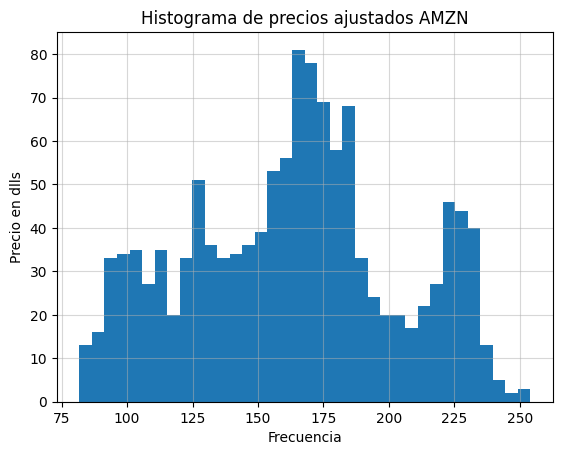

In [239]:
ticker = "AMZN"

# Obtenemos la serie de los precios ajustados de cierre del ticker seleccionado, sin incluir valores nulos
adjusted_prices_ticker = prices["ADJ_CLOSE_"+ticker].dropna()

# Para definir el numero de bins, sacamos la raiz cuadrada del numero de entradas:
n_bins = math.ceil(math.sqrt(adjusted_prices_ticker.count()))

# Ahora definimos la figura y el histograma
plt.figure()
plt.hist(adjusted_prices_ticker.values, bins=n_bins)
plt.title(f"Histograma de precios ajustados {ticker}")
plt.xlabel("Frecuencia")
plt.ylabel("Precio en dlls")
plt.grid(True, alpha=0.5)
plt.show()

### Histograma de rendimientos ajustados ticker AMAZON


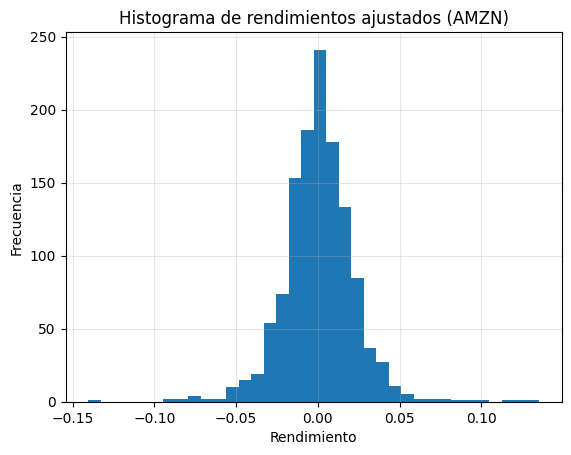

In [240]:
# Obtenemos los rendimientos ajustados del ticker seleccionado 
yield_ticker = adjusted_prices_ticker.pct_change()

# Creamos el histograma
plt.figure()
plt.hist(yield_ticker.values, bins=n_bins)
plt.title(f"Histograma de rendimientos ajustados ({ticker})")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

### Histograma de rendimientos ajustados todos los tickers

Para hacer esta grafica, lo que haremos sera crear una figura y tener multiples subplots en ella. En cada uno de esos subplots se tendra el histograma de rendiemientos ajustados de cada uno de los tickers.

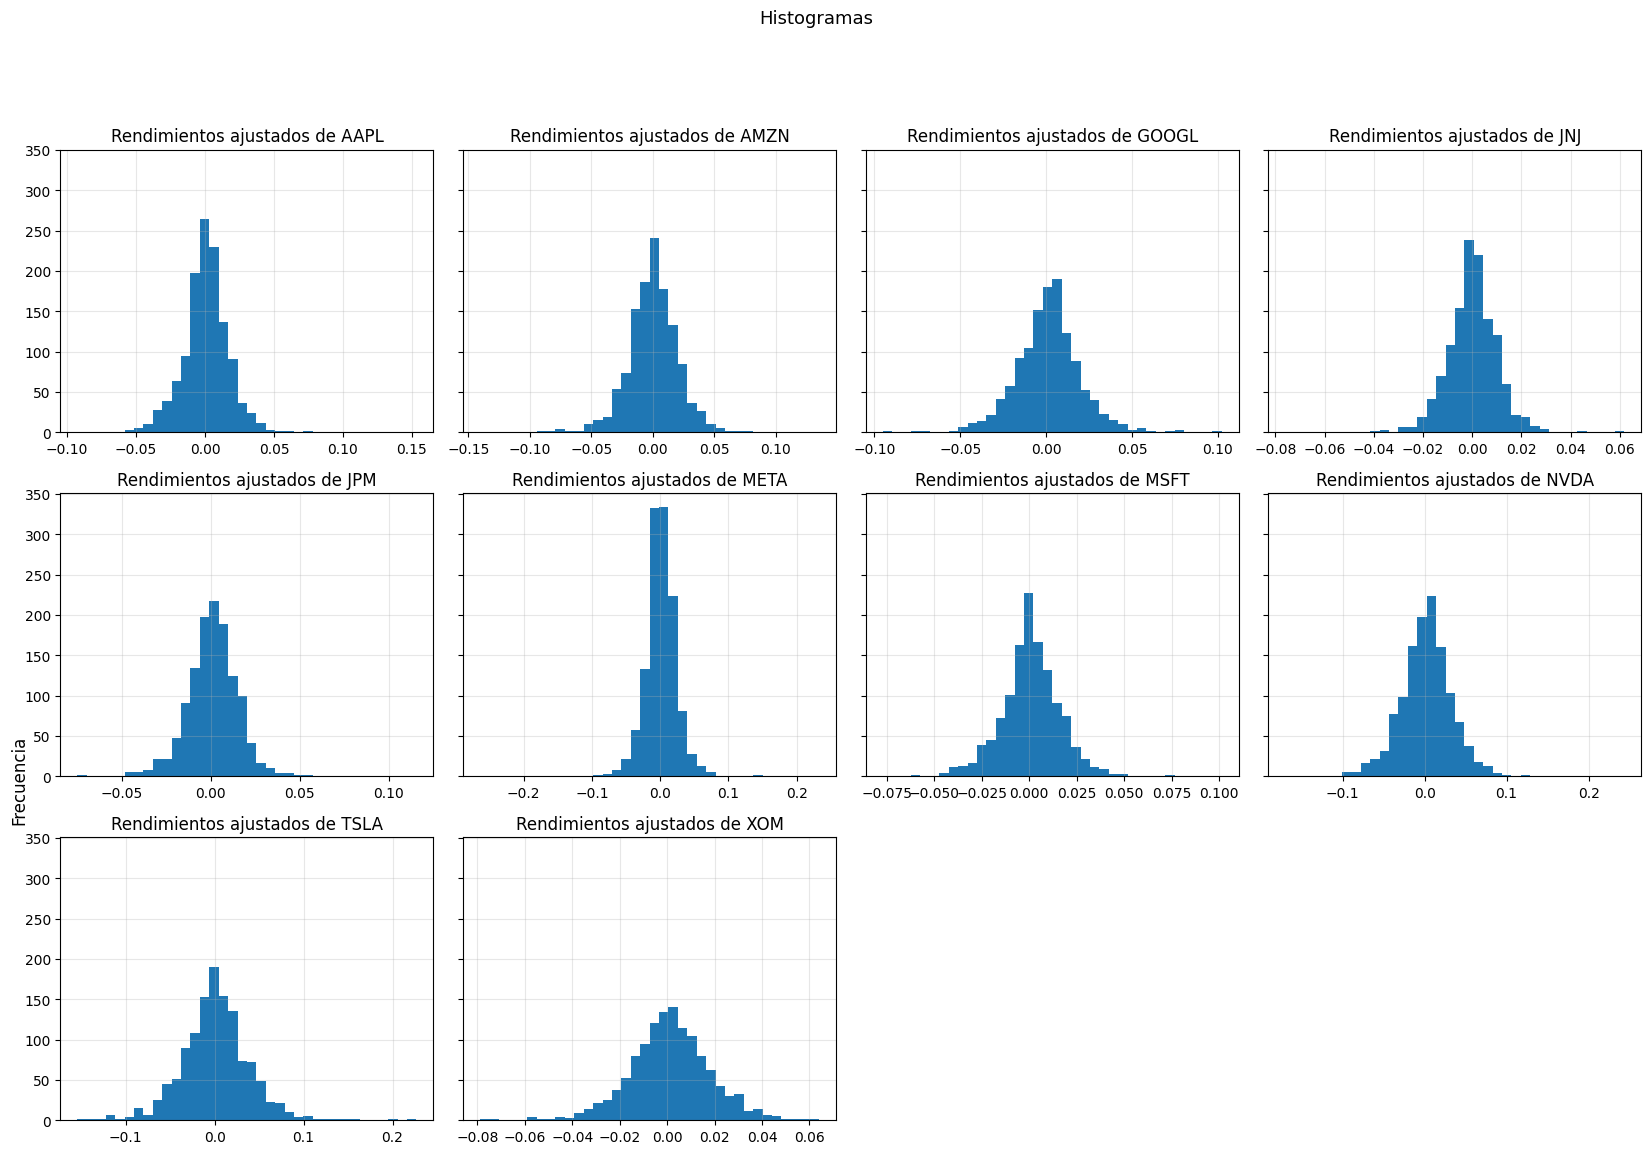

In [241]:
n_rows = math.ceil(math.sqrt(len(price_cols)))
n_cols = n_rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.5*n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()


for i, col in enumerate(price_cols):
    adjusted_yield = prices[col].dropna().pct_change()
    n_bins = math.ceil(math.sqrt(adjusted_yield.count()))
    ax = axes[i]
    ax.hist(adjusted_yield, bins=n_bins)

    ax.set_title(f"Rendimientos ajustados de {col.removeprefix("ADJ_CLOSE_")}")
    ax.grid(True, alpha=0.3)

for k in range(len(price_cols)-1, len(axes)):
    axes[k].set_visible(False)

fig.suptitle("Histogramas", y = 1.05, fontsize=13)
fig.supylabel("Frecuencia")
fig.tight_layout()
plt.show()

## Heatmap

---

Ahora formulamos el codigo para generar los mapas de calor.

### Correlacion de precios ajustados

Para hacer un mapa de calor, tenemos que hacer:

- Definir dataset con valores para calcular matrix de correlaciones
- Obtener la matriz de correlaciones
- Definir un subplot con 1 eje
- Definir el mapa de calor (especificando la matriz de correlaciones, el mapa de color, el valor minimo y el maximo)
- Agregar la barra de color
- Ajustar ticks y labels
- Agregar texto en cada entrada del mapa de calor


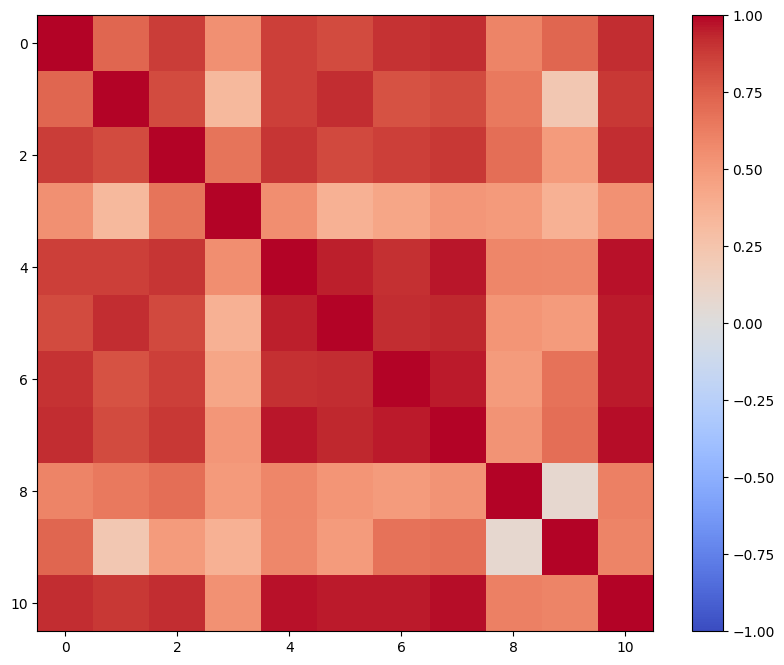

In [242]:
# El siguiente codigo genera la forma mas basica (y peor hecha) del mapa de calor, con un colorbar

heatmap_prices = prices.copy()
heatmap_prices = heatmap_prices.drop(columns="Date")
labels = [col.removeprefix("ADJ_CLOSE_") for col in heatmap_prices.columns]
corr_matrix = heatmap_prices.corr(method="pearson")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
hm = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(hm, ax=ax)
plt.show()


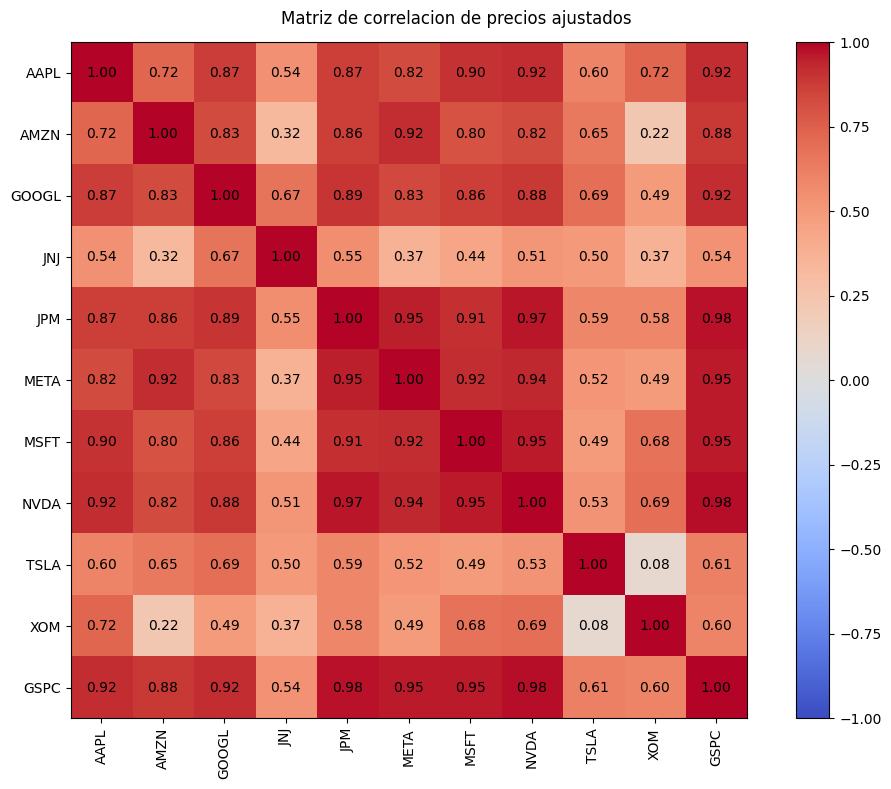

In [243]:

heatmap_prices = prices.copy()
heatmap_prices = heatmap_prices.drop(columns="Date")
labels = [col.removeprefix("ADJ_CLOSE_") for col in heatmap_prices.columns]
corr_matrix = heatmap_prices.corr(method="pearson")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
hm = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

# Se ajustan los ticks del eje x y y, y se ponen las etiquetas adecuadas
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

# Se agrega el texto con los valores de la matrix de correlacion

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(i, j, f"{corr_matrix.values[i,j]:.2f}", ha="center", va="center", color="black")

fig.suptitle("Matriz de correlacion de precios ajustados")
fig.tight_layout()
plt.colorbar(hm, ax=ax)
plt.show()

### Correlacion de rendimientos ajustados y correlacion de precios ajustados

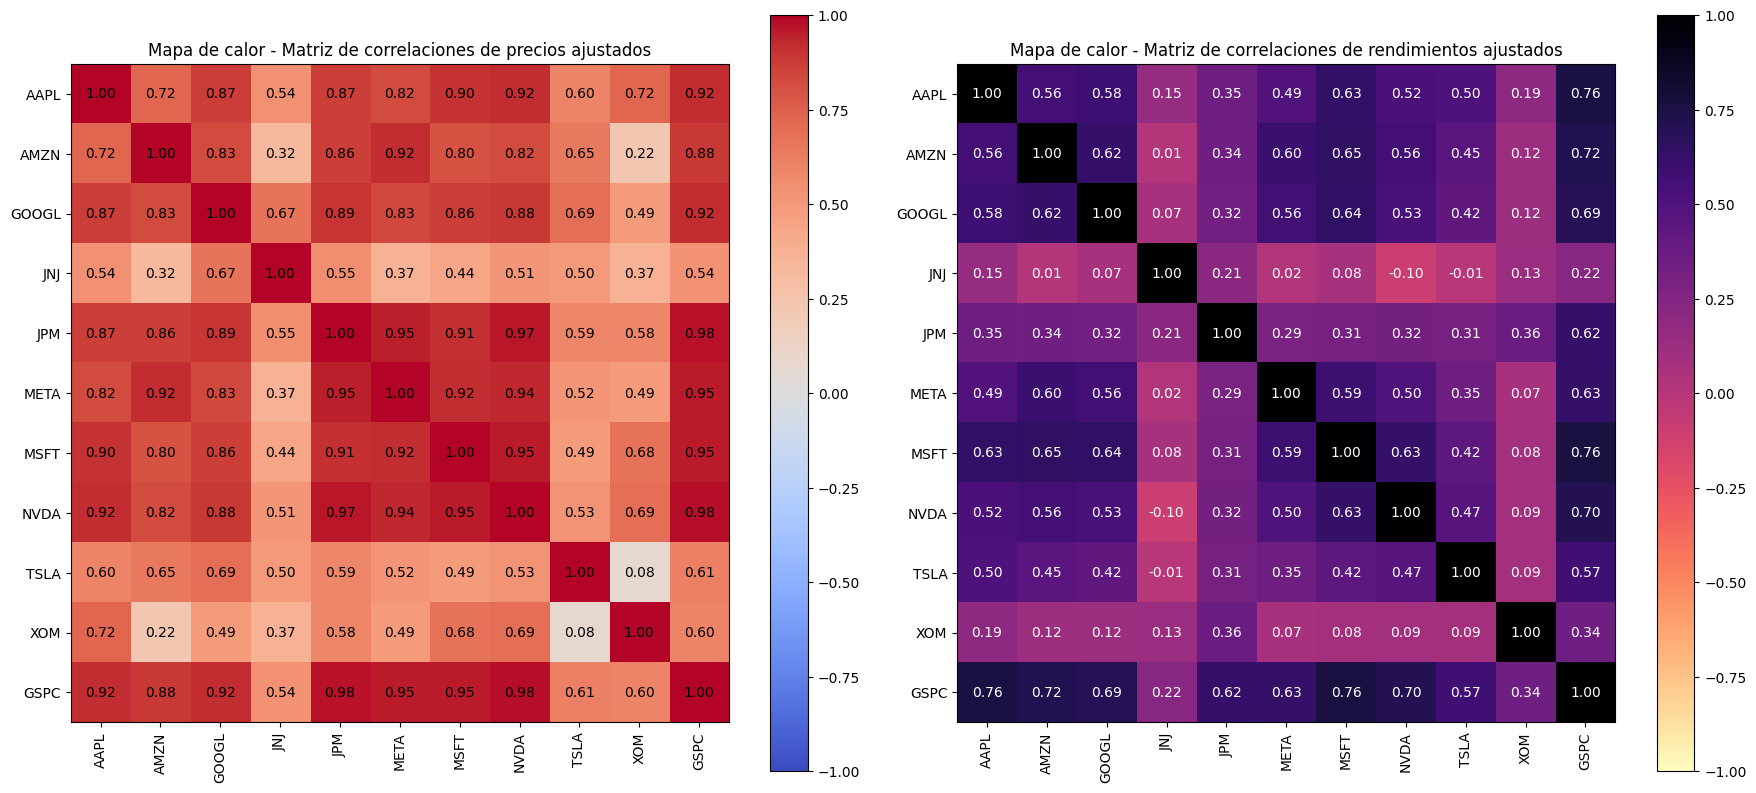

In [244]:
heatmap_prices_v2 = heatmap_prices.copy()
heatmap_prices_v2 = heatmap_prices_v2.pct_change().dropna()

corr_matrix_yields = heatmap_prices_v2.corr(method="pearson")

fig, (ax, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18,8))

im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
im_2 = ax2.imshow(corr_matrix_yields, cmap="magma_r", vmin=-1, vmax=1)
plt.colorbar(im_2, ax=ax2)

for axis in (ax, ax2):

    axis.set_xticks(range(len(labels)))
    axis.set_yticks(range(len(labels)))
    axis.set_xticklabels(labels, rotation=90)
    axis.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            axis.text(i, j, f"{corr_matrix.values[i,j]:.2f}", ha="center", va='center', color="black") if axis == ax else axis.text(i, j, f"{corr_matrix_yields.values[i,j]:.2f}", ha="center", va="center", color="white")

ax.set_title(("Mapa de calor - Matriz de correlaciones de precios ajustados"))
ax2.set_title(("Mapa de calor - Matriz de correlaciones de rendimientos ajustados"))

fig.tight_layout()

## Boxplot

Un grafico de boxplot muestra:

- Quartiles
- La media
- El promedio
- El rango intercuantilico
- La kurtosis
- The skewness
- Maximo y minimo (si se muestran outliers)

Su elaboracion es simple, pues el metodo .boxplot hace todos los calculos necesarios. 

### Boxplot precios ajustados ticker AMZN y GOOGL


C:\Users\ossia\AppData\Local\Temp\ipykernel_14108\81827114.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([adj_prices_boxplot, adj_prices_boxplot2], labels=[ticker, ticker2], showfliers=True)


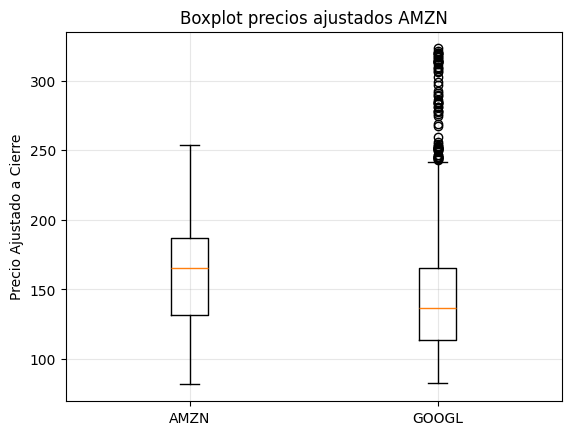

In [245]:
ticker="AMZN"
ticker2="GOOGL"

adj_prices_boxplot = prices["ADJ_CLOSE_"+ticker].dropna()
adj_prices_boxplot2 = prices["ADJ_CLOSE_"+ticker2].dropna()

plt.boxplot([adj_prices_boxplot, adj_prices_boxplot2], labels=[ticker, ticker2], showfliers=True)


plt.title(f"Boxplot precios ajustados {ticker}")
plt.ylabel("Precio Ajustado a Cierre")
plt.grid(True, alpha=0.3)
plt.show()


## Grafico de pie

Un grafico de pie muestra la proporcion de cada unidad que forma un total, con respecto a dicho total. Por tanto, para usar este tipo de grafico primero necesitamos tener bien definido lo que ese 'total' representa. Siguiendo el ejemplo de esta libreta, nuestro total representara un portafolio, para el cual tendremos que definir los pesos de cada accion.

### Grafico de pie de la distribucion por peso en la cartera


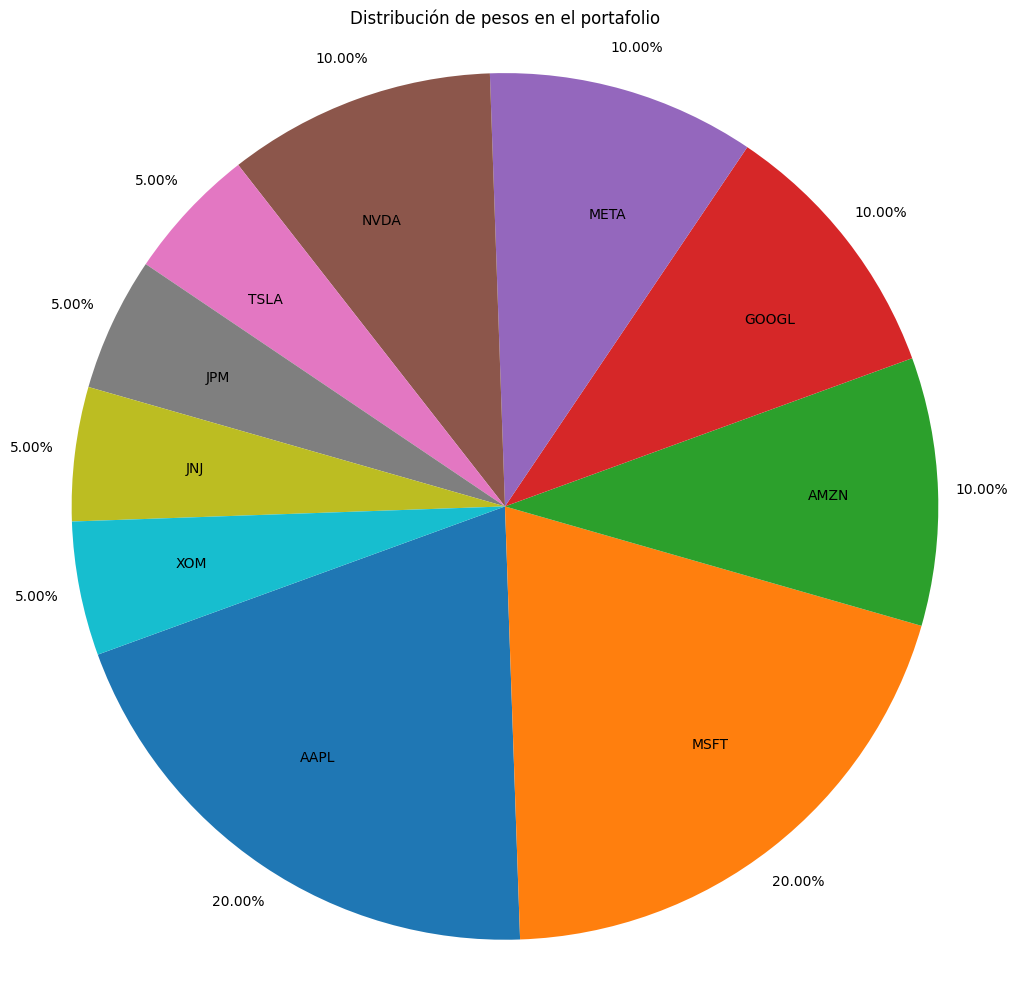

In [246]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

plt.figure(figsize=(10,10))
plt.pie(weights.values(), labels=weights.keys(), startangle=200, autopct="%1.2f%%", labeldistance=.7, pctdistance=1.1)
plt.title("Distribución de pesos en el portafolio")
plt.axis("equal")
plt.tight_layout()
plt.show()

### Proporcion del rendimiento total acumulado por accion para el 2025


In [262]:
# Generamos un dataframe con la informacion relevante

adjusted_yield_2025 = prices.copy()
adjusted_yield_2025 = adjusted_yield_2025.dropna()

adjusted_yield_2025["Date"] = pd.to_datetime(adjusted_yield_2025["Date"], errors="coerce")
adjusted_yield_2025 = adjusted_yield_2025.drop(columns=["ADJ_CLOSE_GSPC"]).sort_values("Date")

first_day_2025 = pd.Timestamp("2025-01-01")
last_day_2025 = pd.Timestamp("2025-12-31")

days_in_2025 = (adjusted_yield_2025["Date"] >= first_day_2025) & (adjusted_yield_2025["Date"] <= last_day_2025)

adjusted_yield_2025 = adjusted_yield_2025.loc[days_in_2025]

# Generamos la grafica

price_cols_without_GSPC = price_cols.copy()
price_cols_without_GSPC = [col.removeprefix("ADJ_CLOSE_") for col in price_cols_without_GSPC if "GSPC" not in col]

display(price_cols_without_GSPC)
display(adjusted_yield_2025)



['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
1005,2025-01-02,242.525162,220.220001,188.558273,139.003418,232.778076,596.845398,414.568573,138.264709,379.279999,102.825630
1006,2025-01-03,242.037811,224.190002,190.907394,139.167511,235.959396,602.213806,419.292877,144.422684,410.440002,103.352654
1007,2025-01-06,243.668915,227.610001,195.964020,138.655975,234.808990,627.681641,423.749756,149.381042,411.049988,103.237671
1008,2025-01-07,240.894073,222.110001,194.590408,141.136444,237.070801,615.420837,418.322266,140.094086,394.359985,104.205452
1009,2025-01-08,241.381409,222.130005,193.057495,137.314377,237.031815,608.279419,420.491302,140.064102,394.940002,102.461517
...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,322.814331,664.371155,485.741333,189.199768,485.559998,118.629288
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,326.023376,666.978943,486.908630,188.599792,485.399994,118.430618
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,324.775421,662.722595,486.599365,190.519684,475.190002,118.321342
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,320.655182,658.126526,485.990753,188.209808,459.640015,119.731941


In [ ]:
#